In [1]:
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sys.path.append(os.path.abspath('../src'))

from data_prep import load_and_merge_tcga
from classification_calculations import calculate_oncotype_dx_score, calculate_pam50_score, calculate_bci_score, fetch_pam50_centroids, calculate_mammostrat_score, calculate_ihc4_score, calculate_kim10_tnbc_score, calculate_irrs7_score, calculate_hu11_irg_score


Error importing in API mode: ImportError("dlopen(/Users/imogen/Capstone/.venv/lib/python3.14/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2850CA86-548E-329D-B1A9-3A70C1623ACC> /Users/imogen/Capstone/.venv/lib/python3.14/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


In [2]:
rna_file = "../data/raw/Human__TCGA_BRCA__UNC__RNAseq__HiSeq_RNA__01_28_2016__BI__Gene__Firehose_RSEM_log2.cct" 
clinical_file = "../data/raw/Human__TCGA_BRCA__MS__Clinical__Clinical__01_28_2016__BI__Clinical__Firehose.tsi"

master_df = load_and_merge_tcga(rna_file, clinical_file)

master_df.head()

Loading datasets...
Merge complete. Final dataset has 1093 patients and 20175 features.


attrib_name,years_to_birth,Tumor_purity,pathologic_stage,pathology_T_stage,pathology_N_stage,pathology_M_stage,histological_type,number_of_lymph_nodes,PAM50,ER.Status,...,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,psiTPTE22,tAKR
TCGA.5L.AAT0,42,0.6501,stageii,t2,n0,m0,infiltratinglobularcarcinoma,0,NaN,NaN,...,6.1217,9.3320,10.1250,4.0737,9.2934,12.0130,9.8504,10.0536,6.4272,0.0000
TCGA.5L.AAT1,63,0.5553,stageiv,t2,n0,m1,infiltratinglobularcarcinoma,0,NaN,NaN,...,5.5181,9.1524,9.9507,5.7758,9.0069,12.1095,10.4641,9.1545,5.8793,0.0000
TCGA.A1.A0SP,40,0.6913,stageii,t2,n0,m0,infiltratingductalcarcinoma,0,Basal,NaN,...,4.8072,8.1959,10.0244,7.9219,9.4147,11.7628,9.4979,10.4667,4.0288,0.4487
TCGA.A2.A04V,39,0.8341,stageii,t2,n0,m0,infiltratingductalcarcinoma,0,LumA,NaN,...,5.3260,9.0582,9.9070,3.1935,9.4548,12.0014,9.1868,9.7472,5.3405,0.0000
TCGA.A2.A04Y,53,0.7318,stageii,t2,n1,m0,infiltratingductalcarcinoma,1,LumB,NaN,...,4.9280,8.1968,10.0861,7.2500,9.6310,11.4851,10.0020,9.6467,8.3197,0.0000


In [3]:
master_df['OncotypeDX_Score'] = calculate_oncotype_dx_score(master_df)

ONCOTYPEDX_CUTOFF = master_df['OncotypeDX_Score'].median()

master_df['OncotypeDX_Class'] = (master_df['OncotypeDX_Score'] > ONCOTYPEDX_CUTOFF).astype(int)

print(f"Empirical ONCOTYPEDX Cut-off (Median): {ONCOTYPEDX_CUTOFF:.4f}")
print(f"High Risk Patients: {master_df['OncotypeDX_Class'].sum()}")
print(f"Low Risk Patients: {(master_df['OncotypeDX_Class'] == 0).sum()}")

Oncotype DX: Found 16/16 genes
Empirical ONCOTYPEDX Cut-off (Median): 11.4928
High Risk Patients: 546
Low Risk Patients: 547


In [4]:
pam50_centroids = fetch_pam50_centroids()

master_df['Pam50_Subtype'], master_df['Pam50_Score'] = calculate_pam50_score(master_df, pam50_centroids)

PAM50_CUTOFF = master_df['Pam50_Score'].median()
master_df['Pam50_Class'] = (master_df['Pam50_Score'] > PAM50_CUTOFF).astype(int)

print(f"Empirical Pam50 Cut-off (Median): {PAM50_CUTOFF:.4f}")
print(f"High Risk Patients: {master_df['Pam50_Class'].sum()}")
print(f"Low Risk Patients: {(master_df['Pam50_Class'] == 0).sum()}")

Empirical Pam50 Cut-off (Median): -0.0163
High Risk Patients: 546
Low Risk Patients: 547


In [5]:
master_df['BCI_Score'] = calculate_bci_score(master_df)

BCI_CUTOFF = master_df['BCI_Score'].median()

master_df['BCI_Class'] = (master_df['BCI_Score'] > BCI_CUTOFF).astype(int)

print(f"Empirical BCI Cut-off (Median): {BCI_CUTOFF:.4f}")
print(f"High Risk Patients: {master_df['BCI_Class'].sum()}")
print(f"Low Risk Patients: {(master_df['BCI_Class'] == 0).sum()}")

Empirical BCI Cut-off (Median): 2.9948
High Risk Patients: 546
Low Risk Patients: 547


In [6]:
master_df['Mammostrat_Score'] = calculate_mammostrat_score(master_df)

Mammostrat_CUTOFF = master_df['Mammostrat_Score'].median()

master_df['Mammostrat_Class'] = (master_df['Mammostrat_Score'] > Mammostrat_CUTOFF).astype(int)

print(f"Empirical Mammostrat Cut-off (Median): {Mammostrat_CUTOFF:.4f}")
print(f"High Risk Patients: {master_df['Mammostrat_Class'].sum()}")
print(f"Low Risk Patients: {(master_df['Mammostrat_Class'] == 0).sum()}")

Empirical Mammostrat Cut-off (Median): 9.7317
High Risk Patients: 546
Low Risk Patients: 547


In [7]:
master_df['IHC4_Score'] = calculate_ihc4_score(master_df)

IHC4_CUTOFF = master_df['IHC4_Score'].median()

master_df['IHC4_Class'] = (master_df['IHC4_Score'] > IHC4_CUTOFF).astype(int)

print(f"Empirical IHC4 Cut-off (Median): {IHC4_CUTOFF:.4f}")
print(f"High Risk Patients: {master_df['IHC4_Class'].sum()}")
print(f"Low Risk Patients: {(master_df['IHC4_Class'] == 0).sum()}")

Empirical IHC4 Cut-off (Median): 8.0262
High Risk Patients: 546
Low Risk Patients: 547


In [8]:
master_df['Kim10_Score'] = calculate_kim10_tnbc_score(master_df)

KIM10_CUTOFF = master_df['Kim10_Score'].median()

master_df['Kim10_Class'] = (master_df['Kim10_Score'] > KIM10_CUTOFF).astype(int)

print(f"Empirical Kim-10 Cut-off (Median): {KIM10_CUTOFF:.4f}")
print(f"High Risk Patients: {master_df['Kim10_Class'].sum()}")
print(f"Low Risk Patients: {(master_df['Kim10_Class'] == 0).sum()}")

Empirical Kim-10 Cut-off (Median): 15.8650
High Risk Patients: 546
Low Risk Patients: 547


In [9]:
master_df['IRRS7_Score'] = calculate_irrs7_score(master_df)

IRRS7_CUTOFF = master_df['IRRS7_Score'].median()

master_df['IRRS7_Class'] = (master_df['IRRS7_Score'] > IRRS7_CUTOFF).astype(int)

print(f"Empirical IRRS7 Cut-off (Median): {IRRS7_CUTOFF:.4f}")
print(f"High Risk Patients: {master_df['IRRS7_Class'].sum()}")
print(f"Low Risk Patients: {(master_df['IRRS7_Class'] == 0).sum()}")

Empirical IRRS7 Cut-off (Median): 4.1233
High Risk Patients: 546
Low Risk Patients: 547


In [10]:
master_df['Hu11_Score'] = calculate_hu11_irg_score(master_df)

Hu11_CUTOFF = master_df['Hu11_Score'].median()

master_df['Hu11_Class'] = (master_df['Hu11_Score'] > Hu11_CUTOFF).astype(int)

print(f"Empirical Hu11 Cut-off (Median): {Hu11_CUTOFF:.4f}")
print(f"High Risk Patients: {master_df['Hu11_Class'].sum()}")
print(f"Low Risk Patients: {(master_df['Hu11_Class'] == 0).sum()}")

Empirical Hu11 Cut-off (Median): 4.2326
High Risk Patients: 546
Low Risk Patients: 547


In [11]:
master_df['OncotypeDX_Score'] = calculate_oncotype_dx_score(master_df)
master_df['Pam50_Subtype'], master_df['Pam50_Score'] = calculate_pam50_score(master_df, pam50_centroids)
master_df['BCI_Score'] = calculate_bci_score(master_df)
master_df['Mammostrat_Score'] = calculate_mammostrat_score(master_df)
master_df['IHC4_Score'] = calculate_ihc4_score(master_df)
master_df['Kim10_Score'] = calculate_kim10_tnbc_score(master_df)
master_df['IRRS7_Score'] = calculate_irrs7_score(master_df)
master_df['Hu11_Score'] = calculate_hu11_irg_score(master_df)

signatures = ['OncotypeDX', 'Pam50', 'BCI', 'Mammostrat', 'IHC4', 'Kim10', 'IRRS7', 'Hu11']

for sig in signatures:
    score_col = f'{sig}_Score'
    class_col = f'{sig}_Class'
    
    median_val = master_df[score_col].median()
    master_df[class_col] = (master_df[score_col] > median_val).astype(int)

master_df['Is_Discordant'] = master_df[
    ['OncotypeDX_Class', 'Pam50_Class', 'BCI_Class', 'Mammostrat_Class', 'IHC4_Class', 'Kim10_Class', 'IRRS7_Class', 'Hu11_Class']
].nunique(axis=1) > 1

print(f"Discordant patients: {master_df['Is_Discordant'].sum()}")
print(f"Patients in agreement across signatures: {1093 - master_df['Is_Discordant'].sum()}")
master_df[master_df['Is_Discordant']][['OncotypeDX_Class', 'Pam50_Class', 'BCI_Class', 'Mammostrat_Class', 'IHC4_Class', 'Kim10_Class', 'IRRS7_Class', 'Hu11_Class', 'Is_Discordant']]


Oncotype DX: Found 16/16 genes
Discordant patients: 1042
Patients in agreement across signatures: 51


attrib_name,OncotypeDX_Class,Pam50_Class,BCI_Class,Mammostrat_Class,IHC4_Class,Kim10_Class,IRRS7_Class,Hu11_Class,Is_Discordant
TCGA.5L.AAT1,0,0,0,0,1,0,1,1,True
TCGA.A1.A0SP,1,1,1,0,1,0,1,0,True
TCGA.A2.A04V,1,0,0,0,1,0,0,1,True
TCGA.A2.A04Y,1,1,0,0,1,1,0,1,True
TCGA.A2.A0CQ,0,0,0,1,0,0,0,1,True
...,...,...,...,...,...,...,...,...,...
TCGA.V7.A7HQ,0,0,0,0,0,0,1,0,True
TCGA.WT.AB44,0,0,0,1,0,0,0,1,True
TCGA.XX.A899,0,0,1,0,0,1,0,1,True
TCGA.XX.A89A,0,0,1,0,0,1,0,1,True


In [12]:
concordant_df = master_df[~master_df['Is_Discordant']].copy()

concordant_df['Consensus_Risk'] = concordant_df['Kim10_Class'].map({
    1: 'High Risk', 
    0: 'Low Risk'
})

columns_to_show = ['OncotypeDX_Class', 'Pam50_Class', 'BCI_Class', 'Mammostrat_Class', 'IHC4_Class', 'Kim10_Class', 'IRRS7_Class', 'Hu11_Class', 'Consensus_Risk']

print(f"Total patients in agreement: {len(concordant_df)}")
print("\nSample of Concordant Patients:")
print(concordant_df[columns_to_show].head(10))

Total patients in agreement: 51

Sample of Concordant Patients:
attrib_name   OncotypeDX_Class  Pam50_Class  BCI_Class  Mammostrat_Class  \
TCGA.5L.AAT0                 0            0          0                 0   
TCGA.A2.A1G4                 0            0          0                 0   
TCGA.A8.A06U                 1            1          1                 1   
TCGA.BH.A8FY                 0            0          0                 0   
TCGA.E2.A572                 0            0          0                 0   
TCGA.A2.A0SV                 1            1          1                 1   
TCGA.A2.A1FZ                 0            0          0                 0   
TCGA.A2.A1G6                 0            0          0                 0   
TCGA.A8.A07U                 1            1          1                 1   
TCGA.A8.A08L                 1            1          1                 1   

attrib_name   IHC4_Class  Kim10_Class  IRRS7_Class  Hu11_Class Consensus_Risk  
TCGA.5L.AAT0       

Generating Signature Correlation Heatmap...


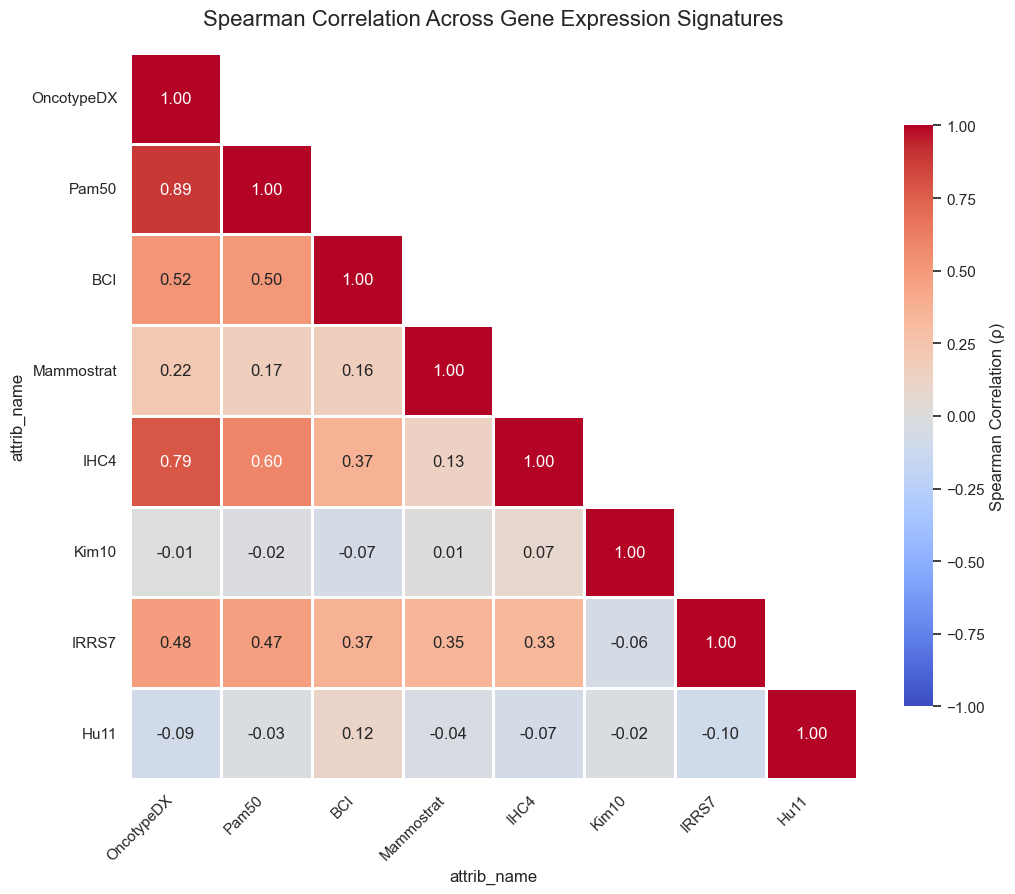

In [ ]:
score_cols = [f'{sig}_Score' for sig in signatures]
score_df = master_df[score_cols]

corr_matrix = score_df.corr(method='spearman')

plt.figure(figsize=(11, 9))
sns.set_theme(style="white") 

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True,          
    fmt=".2f",           
    cmap='coolwarm',     
    vmin=-1, vmax=1,     
    square=True,         
    linewidths=1,        
    cbar_kws={"shrink": .8, "label": "Spearman Correlation (ρ)"}
)

clean_labels = [col.replace('_Score', '') for col in score_cols]
plt.xticks(ticks=np.arange(len(clean_labels)) + 0.5, labels=clean_labels, rotation=45, ha='right', fontsize=11)
plt.yticks(ticks=np.arange(len(clean_labels)) + 0.5, labels=clean_labels, rotation=0, fontsize=11)

plt.title('Spearman Correlation Across Gene Expression Signatures', fontsize=16, pad=20)
plt.tight_layout()
plt.show()